# Problem

In [7]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import random
import torch
import pandas as pd
import sys
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
from matplotlib.colors import LogNorm
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors

# This starts from the current working directory
# and goes up until it finds the 'fogas_torch' folder or '.git'
def find_root(current_path, marker="fogas_torch"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
print(f"Project root found at: {PROJECT_ROOT}")

# Add project root to sys.path so we can import local packages
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
# Now define the dataset path
DATASET_PATH = PROJECT_ROOT / "datasets" / "20_to_40grid.csv"
DATASET_PATH1 = PROJECT_ROOT / "datasets" / "40grid.csv"
print(f"Loading dataset from: {DATASET_PATH}")

from fogas_torch import PolicySolver, EnvDataCollector
from fogas_torch.algorithm import (
    FOGASSolverVectorized,
    FOGASOracleSolverVectorized,
    FOGASHyperOptimizer,
    FOGASEvaluator,
    FOGASDataset,
)
from fogas.dataset_collection.dataset_analyzer import DatasetAnalyzer
from fogas_torch.fqi.fqi_solver import FQISolver
from fogas_torch.fqi.fqi_evaluator import FQIEvaluator

seed = 44
np.random.seed(seed) # Add this
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root found at: /shared/home/mauro.diaz/work/FOGAS
Loading dataset from: /shared/home/mauro.diaz/work/FOGAS/datasets/20_to_40grid.csv
Using device: cuda


# Problem

In [2]:
def plot_fogas_grid(grid_data):
    """
    Visualizes large grids (50x50, 100x100) for RL analysis.
    """
    size = grid_data.shape[0]
    
    # Mapping characters to numeric values for plotting
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)

    # Define a high-contrast color palette
    # Empty (White), Wall (Black), Pit (Red), Start (Blue), Goal (Green)
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    # Set plot size to fit comfortably in a notebook
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Grid lines to help distinguish cells in 50x50
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.3)
        plt.xticks(np.arange(-0.5, size, 5), [])
        plt.yticks(np.arange(-0.5, size, 5), [])
    
    plt.title(f"FOGAS Environment: {size}x{size} Grid", fontsize=15)
    
    # Legend construction
    patches = [
        plt.plot([],[], marker="s", ms=10, ls="", color=colors[i], 
                 label=list(mapping.keys())[i])[0]  for i in range(len(colors))
    ]
    plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    
    plt.tight_layout()
    plt.show()

def scale_grid(small_grid, factor=2):
    """
    Takes a 50x50 grid and turns it into a 100x100 grid 
    by doubling every pixel (cell), making walls and pits twice as thick.
    """
    # Use numpy's repeat to double rows and columns
    large_grid = np.repeat(np.repeat(small_grid, factor, axis=0), factor, axis=1)
    
    # After scaling, we must ensure there is only ONE Start and ONE Goal
    # (Otherwise you'd have a 2x2 block of 'S' and 'G')
    large_grid[large_grid == 'S'] = '.'
    large_grid[large_grid == 'G'] = '.'
    
    large_grid[0, 0] = 'S'
    large_grid[-1, -1] = 'G'
    
    return large_grid

def plot_agent_paths(grid_data, paths, labels=None, title_suffix=""):
    """
    Overlays agent trajectories on the FOGAS grid.
    'paths' should be a list of lists, e.g., [[(0,0), (0,1)...], [(0,0), (1,0)...]]
    'labels' should be a list of strings for the legend.
    """
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(10, 10))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Plot each path with a distinct style
    line_styles = ['-', '--', ':']
    path_colors = ['magenta', 'cyan', 'yellow']
    
    for i, path in enumerate(paths):
        if not path: continue
        
        # Determine current label: use provided list if available, else fallback to default
        path_label = labels[i] if labels and i < len(labels) else f'Agent Path {i+1}'
        
        rows, cols = zip(*path)
        plt.plot(cols, rows, label=path_label, 
                 color=path_colors[i % 3], linestyle=line_styles[i % 3], 
                 linewidth=2, marker='o', markersize=3, alpha=0.8)

    plt.title(f"FOGAS Path Analysis: {size}x{size} {title_suffix}", fontsize=15)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    if size <= 50:
        plt.grid(which='both', color='grey', linestyle='-', linewidth=0.5, alpha=0.2)
        
    plt.tight_layout()
    plt.show()

def compute_optimal_path(mdp, mdp_data, size, max_steps=1000):
    """
    Computes the optimal path from start to goal by following mdp.pi_star 
    and looking up the resulting state in the transition matrix mdp.P.
    """
    current_state = mdp_data["start"]
    goal_state = mdp_data["goal"]
    pits = mdp_data["pits"]
    path = []
    
    for _ in range(max_steps):
        # Convert 1D state index back to 2D (row, col) coordinates
        r, c = divmod(current_state, size)
        path.append((r, c))
        
        # Stop condition: Reached the goal or fell into a pit
        if current_state == goal_state or current_state in pits:
            break
            
        # Extract the optimal action index from the pi_star vector at the current state
        best_a = torch.argmax(mdp.pi_star[current_state]).item()
        
        # Find the next state from the MDP transition matrix P
        # P has shape (N*A, N). The row index is: state * total_actions + action
        next_state = torch.argmax(mdp.P[current_state * mdp.A + best_a]).item()
        
        # Failsafe to prevent getting stuck in a loop against a wall
        if next_state == current_state:
            break
            
        current_state = next_state
        
    return path


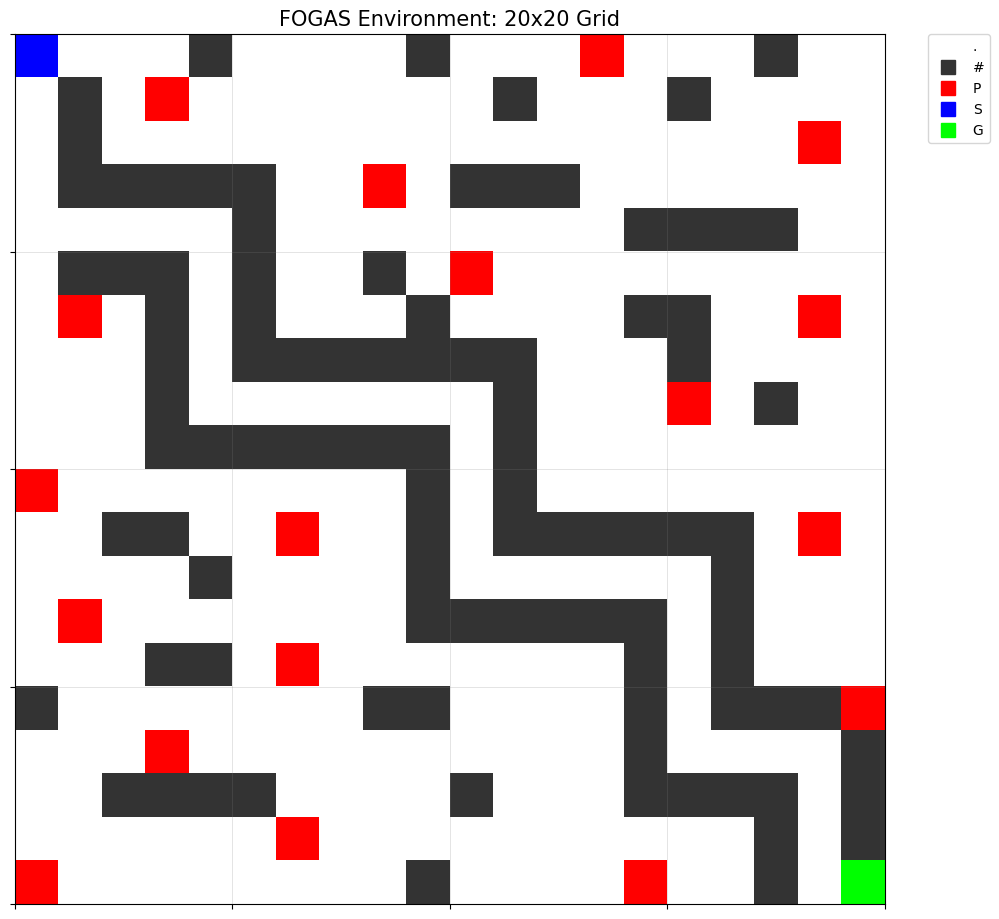

In [3]:
grid_layout = [
    "S...#....#...P...#..",
    ".#.P.......#...#....",
    ".#................P.",
    ".#####..P.###.......",
    ".....#........####..",
    ".###.#..#.P.........",
    ".P.#.#...#....##..P.",
    "...#.#######...#....",
    "...#.......#...P.#..",
    "...#######.#........",
    "P........#.#........",
    "..##..P..#.######.P.",
    "....#....#......#...",
    ".P.......######.#...",
    "...##.P.......#.#...",
    "#.......##....#.###P",
    "...P..........#....#",
    "..####....#...####.#",
    "......P..........#.#",
    "P........#....P..#.G"
]
# Load it as a 2D numpy array (how your environment expects it)
grid_20 = np.array([list(row) for row in grid_layout])
# To test it visually
plot_fogas_grid(grid_20)

# Linear MDP

In [4]:
def generate_mdp_regular_grid(grid_data, gamma=0.99):
    size = grid_data.shape[0]
    N = size * size
    A = 4
    
    walls = set(np.where(grid_data.flatten() == '#')[0])
    pits = set(np.where(grid_data.flatten() == 'P')[0])
    goal = np.where(grid_data.flatten() == 'G')[0][0]
    start_node = np.where(grid_data.flatten() == 'S')[0][0]

    # --- Regular Grid Center Generation ---
    # Target 50% of the total states (N)
    target_num_centers = int(N * 0.5)
    
    # Because we are making a square meshgrid, we need the "centers per side"
    # which is the square root of the target number of centers.
    centers_per_side = int(np.sqrt(target_num_centers))
    
    # Creates a meshgrid in normalized [0, 1] space
    ticks = np.linspace(0.0, 1.0, centers_per_side)
    c_x, c_y = np.meshgrid(ticks, ticks)
    centers = torch.tensor(np.column_stack([c_x.ravel(), c_y.ravel()]), dtype=torch.float64)
    
    def reward_fn(x, a):
        x_int = int(x)
        if x_int == goal: return 10.0
        if x_int in pits: return -10.0
        return -0.01

    P = torch.zeros((N * A, N), dtype=torch.float64)
    for x in range(N):
        for a in range(A):
            if x in pits or x == goal:
                P[x * A + a, x] = 1.0
                continue
            r, c = divmod(x, size)
            if a == 0: r_n, c_n = max(0, r-1), c
            elif a == 1: r_n, c_n = min(size-1, r+1), c
            elif a == 2: r_n, c_n = r, max(0, c-1)
            elif a == 3: r_n, c_n = r, min(size-1, c+1)
            next_s = r_n * size + c_n
            if next_s in walls: next_s = x
            P[x * A + a, next_s] = 1.0

    return {
        "centers": centers, "walls": walls, "pits": pits, 
        "goal": goal, "start": start_node, "reward_fn": reward_fn, 
        "P": P, "N": N, "A": A, "gamma": gamma
    }

def get_phi_state_func(centers, sigma, size, pits, goal):
    """Returns a scale-invariant phi_state function."""
    def phi_state(x):
        # Normalize coordinates based on the current grid size
        r, c = divmod(int(x), size)
        coords = torch.tensor([r / (size - 1), c / (size - 1)], dtype=torch.float64)
        
        # Calculate RBF activations
        dist_sq = torch.sum((coords - centers)**2, dim=1)
        rbf = torch.exp(-dist_sq / (2 * sigma**2))
        
        # Indicator features as per FOGAS standard practice
        is_pit = 1.0 if int(x) in pits else 0.0
        is_goal = 1.0 if int(x) == goal else 0.0
        indicators = torch.tensor([is_pit, is_goal], dtype=torch.float64)
        
        # Feature vector includes RBFs, Bias (1.0), and Indicators
        return torch.cat([rbf, torch.ones(1, dtype=torch.float64), indicators])
    return phi_state

def calculate_local_sigma(centers, k=2):
    """Computes sigma based on k-nearest neighbors for spatial precision."""
    dist_matrix = torch.cdist(centers, centers, p=2)
    topk_dists, _ = torch.topk(dist_matrix, k + 1, largest=False, dim=1)
    return torch.mean(topk_dists[:, 1])

def plot_grid_with_centers(grid_data, centers):
    size = grid_data.shape[0]
    mapping = {'.': 0, '#': 1, 'P': 2, 'S': 3, 'G': 4}
    numeric_grid = np.vectorize(mapping.get)(grid_data)
    
    colors = ['#FFFFFF', '#333333', '#FF0000', '#0000FF', '#00FF00']
    cmap = mcolors.ListedColormap(colors)
    
    plt.figure(figsize=(12, 12))
    plt.imshow(numeric_grid, cmap=cmap)
    
    # Overlay Centers (Scaled back from [0,1] to [0, size-1])
    centers_scaled = centers.numpy() * (size - 1)
    plt.scatter(centers_scaled[:, 1], centers_scaled[:, 0], 
                c='blue', marker='x', s=size, label='RBF Feature Centers', alpha=0.6)
    
    plt.title(f"FOGAS Feature Allocation ({size}x{size})", fontsize=16)
    plt.legend(loc='upper right')
    plt.show()

## 20x20

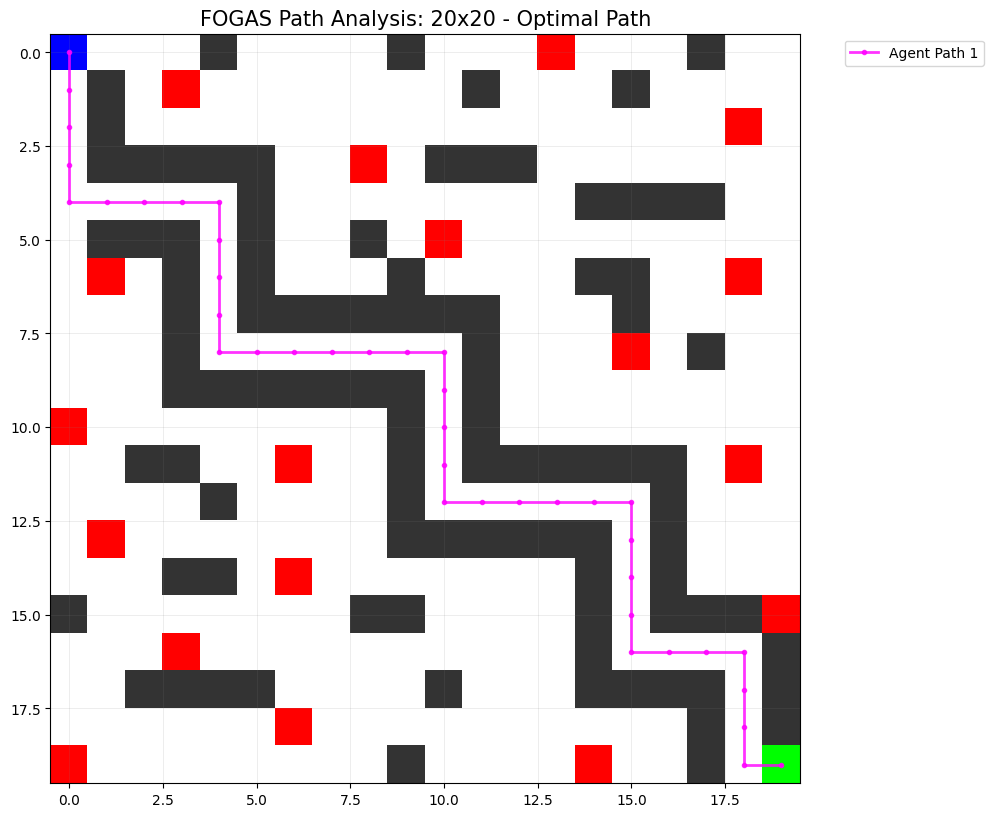

In [13]:
size = 20

# --- STEP 2: Generate MDP Components with Regular Grid ---
# We use 15 centers per side (225 total RBFs) for a 50x50 or 100x100 grid.
mdp_data = generate_mdp_regular_grid(grid_20)

# --- STEP 3: Calculate Scale-Invariant Sigma ---
# Using Local KNN Sigma (k=2) ensures RBFs overlap with neighbors
# but don't become "blurry" across walls.
centers = mdp_data["centers"]
rbf_sigma = calculate_local_sigma(centers, k=2)

# --- STEP 4: Define the Scale-Invariant Phi Functions ---
# Note: size is passed here to ensure normalization: r / (size-1)
phi_s = get_phi_state_func(
    centers, 
    rbf_sigma, 
    size, 
    mdp_data["pits"], 
    mdp_data["goal"]
)

def phi(x, a):
    """Coupled Feature Map: phi(x, a) = e_a ⊗ phi_state(x)"""
    s_feat = phi_s(x)
    A = 4
    e_a = torch.zeros(A, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# Calculate Feature Dimension d
sample_feat = phi(0, 0)
d = int(sample_feat.shape[0])

# --- STEP 5: Create the FOGAS Solver Object ---
# (Assumes your PolicySolver class is defined as in your previous code)
states = torch.arange(size * size, dtype=torch.int64)
actions = torch.arange(4, dtype=torch.int64)

mdp = PolicySolver(
    states=states, 
    actions=actions, 
    phi=phi,
    reward_fn=mdp_data["reward_fn"], 
    gamma=mdp_data["gamma"], 
    x0=mdp_data["start"], 
    P=mdp_data["P"]
)
optimal_path = compute_optimal_path(mdp, mdp_data, size=size)
# 2. Plot the trajectory
plot_agent_paths(grid_20, [optimal_path], title_suffix="- Optimal Path")

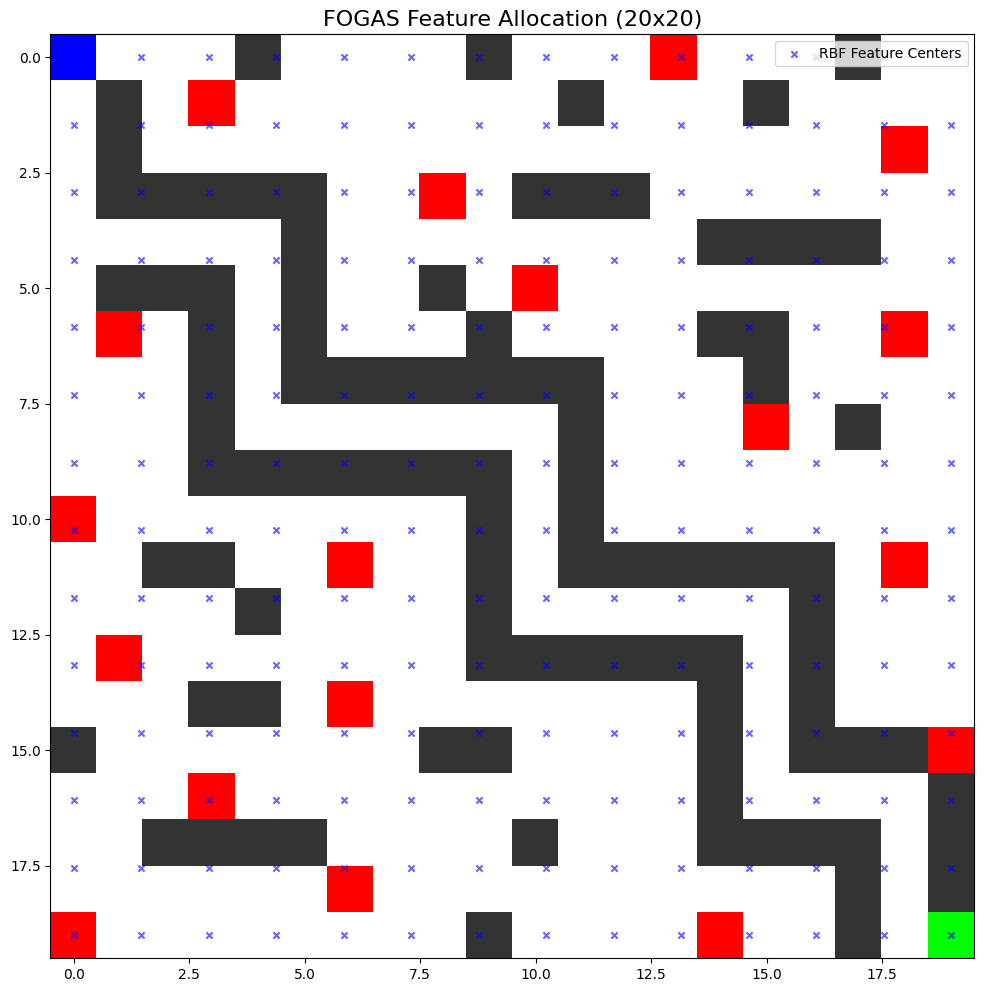

In [14]:
plot_grid_with_centers(grid_data=grid_20, centers=centers)

### Dataset creation

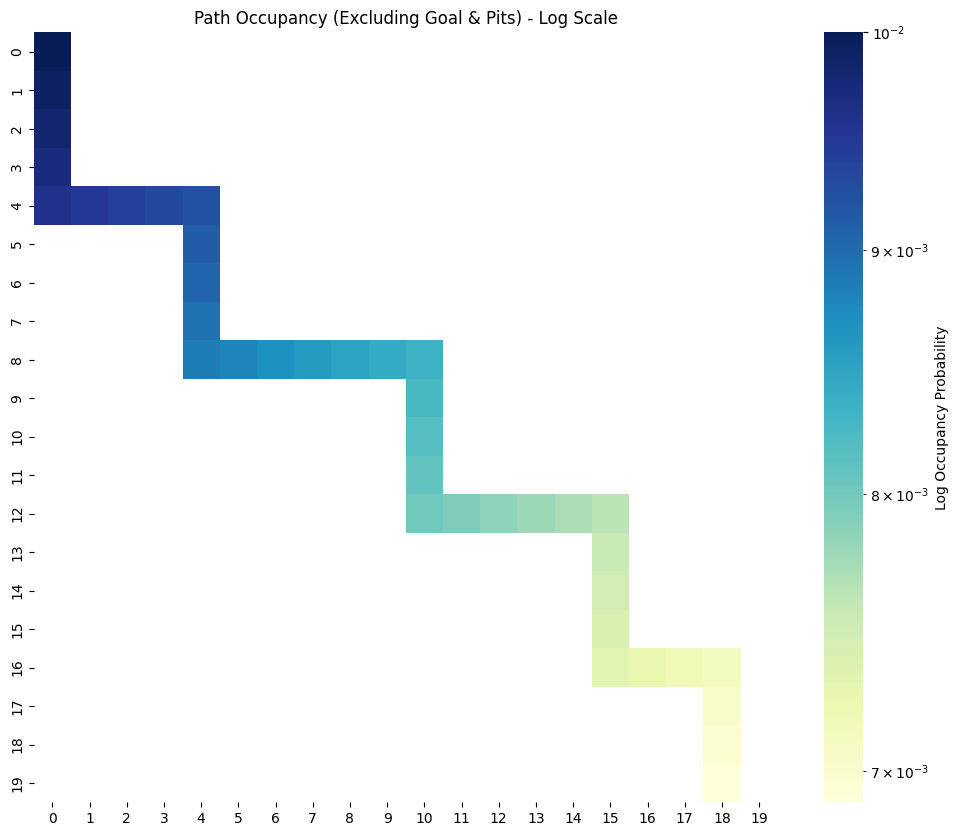

In [15]:
# 1. Get occupancy probabilities
probs = mdp.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# The goal index is usually size*size - 1
terminal_indices = list(mdp_data['pits']) + [mdp_data['goal']]
for idx in terminal_indices:
    probs[idx] = 0.0

# 3. Reshape
grid_size = size
occupancy_grid = probs.reshape(grid_size, grid_size)

# 4. Plot with Log Normalization to see small probabilities along the path
plt.figure(figsize=(12, 10))
sns.heatmap(occupancy_grid, 
            cmap="YlGnBu", 
            norm=LogNorm(vmin=probs[probs>0].min() if any(probs>0) else 1e-6, vmax=probs.max()),
            cbar_kws={'label': 'Log Occupancy Probability'})

plt.title("Path Occupancy (Excluding Goal & Pits) - Log Scale")
plt.show()


In [16]:
reset_options = {
    'x0': 0.1, 
    'occupancy': 0.9
}

# Initialize the collector with these options
collector = EnvDataCollector(
    mdp=mdp,
    env_name="50grid",
    restricted_states=mdp_data["walls"],  # These will never be starting states
    reset_probs=reset_options,
    max_steps=100
)

# Create an epsilon-greedy pi_star (30% optimal, 70% random)
epsilon_policy = (mdp.pi_star, 0.3)

df = collector.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy, "random"],  
    proportions=[0.8, 0.2],
    n_steps=20000,
    episode_based=True,                   
    save_path=str(DATASET_PATH),
    verbose=True,
    extra_steps=20 
)


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 20000
Total episodes: 340
Extra steps: 20

Policy Distribution:
  Policy 0: 14876 steps (74.4%) | Target: 80.0% | Episodes: 283
  Policy 1:  5124 steps (25.6%) | Target: 20.0% | Episodes: 58

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/20_to_40grid.csv


In [17]:
analyzer = DatasetAnalyzer(DATASET_PATH)

ratio = analyzer.feature_coverage_ratio(
    mdp=mdp,
    beta=1e-6,
    use_optimal_policy=True,
    verbose=True,
    return_details=True,
)


Feature Coverage Ratio Details
------------------------------
  Dataset size (n):         20000
  MDP dims (N, A, d):        (400, 4, 796)
  gamma:                    0.99
  beta (ridge):             1e-06
  policy source:            provided

  Occupancy μ_pi summary:
    sum:                    1
    min / max:              0 / 0.682555

  Feature occupancy λ_pi summary:
    ||λ||_2:                1.38026
    ||λ||_1:                5.61732
    max |λ_i|:              0.682555

  Empirical covariance Λ_n:
    diag min / mean / max:  1e-06 / 0.00505699 / 0.318851
    eig min / max:          1e-06 / 0.904185
    condition number:       904185

  Coverage ratio:           2.44983


Total states: 400
Walls: 98
Visited: 58
Non-visited non-walls: 244


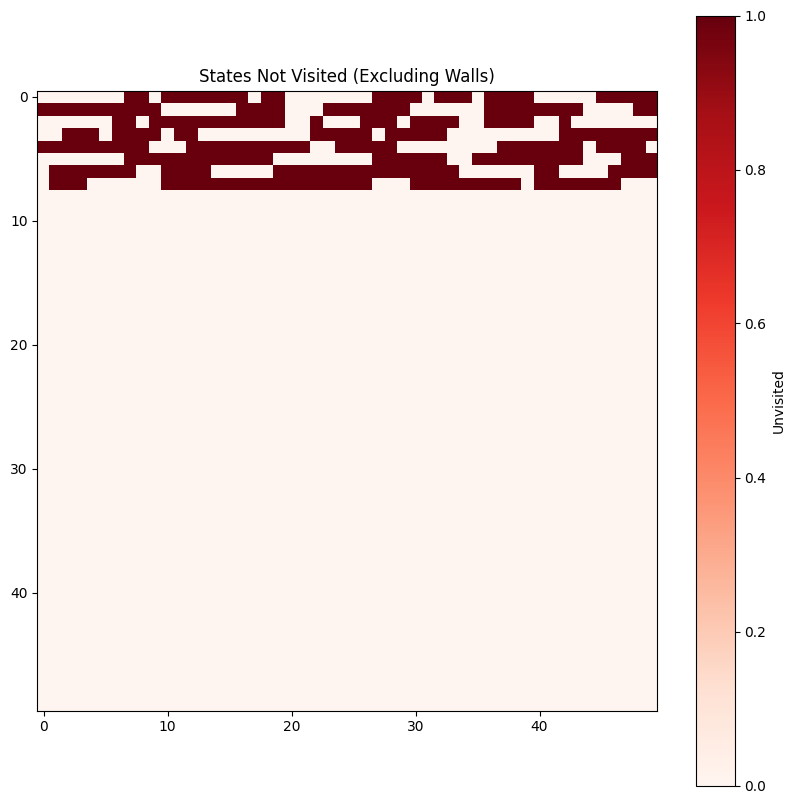

In [18]:
# 1. Get all visited states from your collected dataset
visited_states = set(df['state'].unique())

# 2. Get the set of wall states
# Since you are in the 50x50grid notebook, mdp_data contains the wall indices
wall_states = set(mdp_data['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states = set(range(mdp.N))
non_visited_non_walls = all_states - visited_states - wall_states

print(f"Total states: {mdp.N}")
print(f"Walls: {len(wall_states)}")
print(f"Visited: {len(visited_states)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls)}")

# Optional: Convert indices to (row, col) coordinates for the 50x50 grid
size = 50
coords = [divmod(s, size) for s in sorted(list(non_visited_non_walls))]
# print(coords[:10]) # Show first 10 missing states

# Create an empty 50x50 map (0 = visited/wall, 1 = missing)
coverage_map = np.zeros((size, size))
for s in non_visited_non_walls:
    r, c = divmod(s, size)
    coverage_map[r, c] = 1
plt.figure(figsize=(10, 10))
plt.imshow(coverage_map, cmap='Reds')
plt.title("States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()


### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=20000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                        2.122004
Mean |error|                       0.121390
RMSE                               0.251678
R² (explained variance)            0.986667


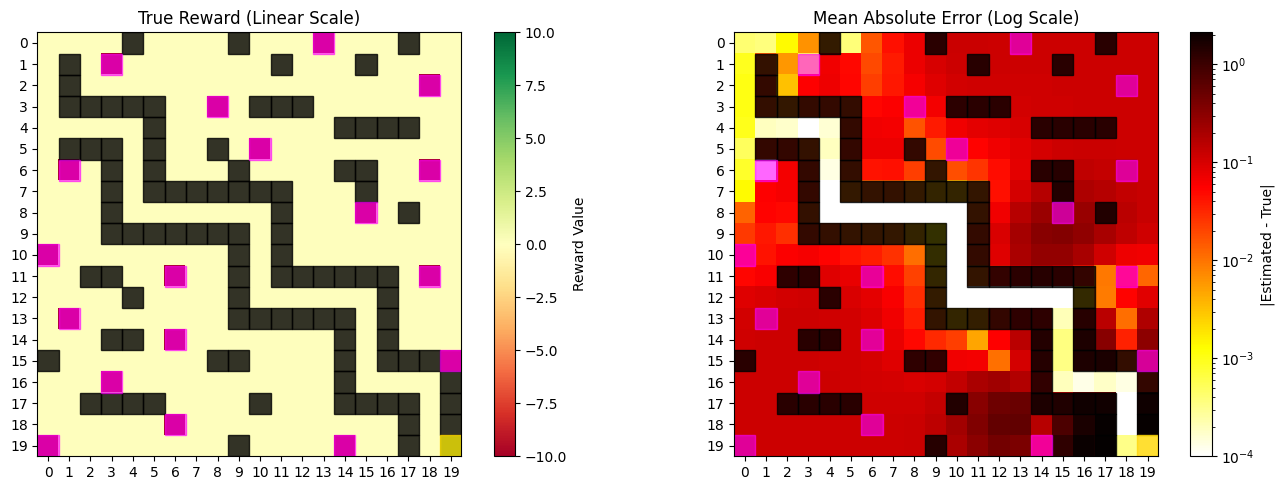

In [19]:
solver_e = FOGASSolverVectorized(
    mdp=mdp,
    csv_path=str(DATASET_PATH),
    device=device,
    beta=1e-7,
    seed=seed)
evaluator_e = FOGASEvaluator(solver_e)
optimizer_e = FOGASHyperOptimizer(solver=solver_e,metric_callable=evaluator_e.get_metric("reward"), seed=seed)

evaluator_e.analyze_reward_approximation(
    walls=mdp_data["walls"], 
    pits=mdp_data["pits"], 
    goal=mdp_data["goal"]
    )

In [20]:
# Run solver with best alpha and fixed rho, eta
solver_e.run(alpha=0.0001, eta=0.00002, rho=0.5, tqdm_print=True, T=25000)
evaluator_e.print_optimal_path(goal_state=mdp_data["goal"])

FOGAS: 100%|█████████████████████████████| 25000/25000 [00:45<00:00, 543.72it/s]



  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 399
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 20
  Step   1 │ State: 20       │ Action: 1       │ Reward:  -0.010 │ → 40
  Step   2 │ State: 40       │ Action: 1       │ Reward:  -0.010 │ → 60
  Step   3 │ State: 60       │ Action: 1       │ Reward:  -0.010 │ → 80
  Step   4 │ State: 80       │ Action: 3       │ Reward:  -0.010 │ → 81
  Step   5 │ State: 81       │ Action: 3       │ Reward:  -0.010 │ → 82
  Step   6 │ State: 82       │ Action: 3       │ Reward:  -0.010 │ → 83
  Step   7 │ State: 83       │ Action: 3       │ Reward:  -0.010 │ → 84
  Step   8 │ State: 84       │ Action: 1       │ Reward:  -0.010 │ → 104
  Step   9 │ State: 104      │ Action: 1       │ Reward:  -0.010 │ → 124
  Step  10 │ State: 124      │ Action: 1       │ Reward:  -0.010 │ → 144
  Step  11 │ St

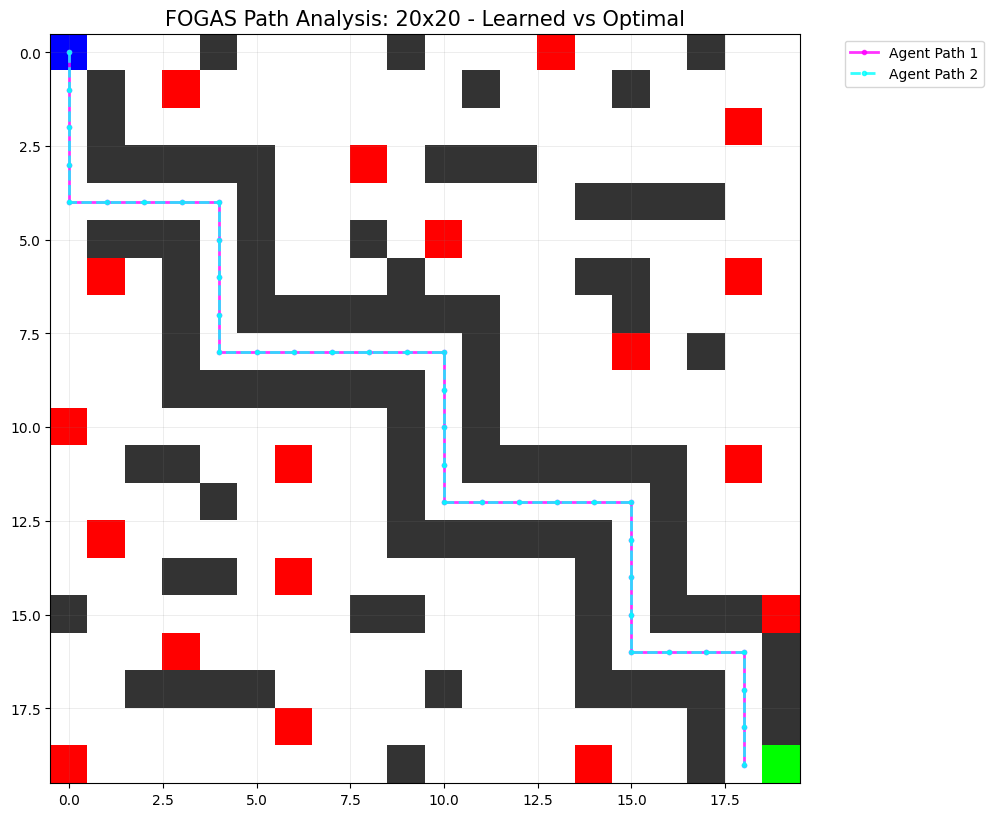

In [21]:
traj = evaluator_e.simulate_trajectory(goal_state=mdp_data["goal"])
# 2. Extract the state indices and convert them to (row, col) coordinates
size = grid_20.shape[0]
path_coords = [divmod(step['state'], size) for step in traj]
# Simulate the optimal policy trajectory
traj_opt = evaluator_e.simulate_trajectory(pi=evaluator_e.mdp.pi_star, goal_state=mdp_data["goal"])
path_opt = [divmod(step['state'], size) for step in traj_opt]

# Plot both to see how close your learned policy is to optimal
plot_agent_paths(grid_20, [path_coords, path_opt], title_suffix="- Learned vs Optimal")

## 40x40

In [5]:
# 1. Define base grid and scale it
grid_20 = np.array([list(row) for row in grid_layout])
grid_40 = scale_grid(grid_20, factor=2)
size_20, size_40 = grid_20.shape[0], grid_40.shape[0]

# 2. Generate MDP components freshly
mdp_data_20 = generate_mdp_regular_grid(grid_20)
mdp_data_40 = generate_mdp_regular_grid(grid_40)

# 3. Extract the ground-truth feature space
fixed_centers = mdp_data_20["centers"]
fixed_sigma = calculate_local_sigma(fixed_centers, k=2)

# 4. Explicitly redefine the 20x20 feature map to avoid stale closures
phi_s_20 = get_phi_state_func(fixed_centers, fixed_sigma, size_20, mdp_data_20["pits"], mdp_data_20["goal"])

def phi_20_fixed(x, a):
    s_feat = phi_s_20(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# 5. Define the 40x40 feature map using the exact same centers
phi_s_40 = get_phi_state_func(fixed_centers, fixed_sigma, size_40, mdp_data_40["pits"], mdp_data_40["goal"])

def phi_40_fixed(x, a):
    s_feat = phi_s_40(x)
    e_a = torch.zeros(4, dtype=torch.float64)
    e_a[int(a)] = 1.0
    return torch.kron(e_a, s_feat)

# --- STEP 7: Create the FOGAS Solver Object for 40x40 ---
# Ensure we are using the correct state and action spaces for the 40x40 grid
states_40 = torch.arange(size_40 * size_40, dtype=torch.int64)
actions_40 = torch.arange(4, dtype=torch.int64)

# Initialize the solver
mdp_40 = PolicySolver(
    states=states_40, 
    actions=actions_40, 
    phi=phi_40_fixed,          # The rigorously aligned feature map
    reward_fn=mdp_data_40["reward_fn"], 
    gamma=mdp_data_40["gamma"], 
    x0=mdp_data_40["start"], 
    P=mdp_data_40["P"]
)

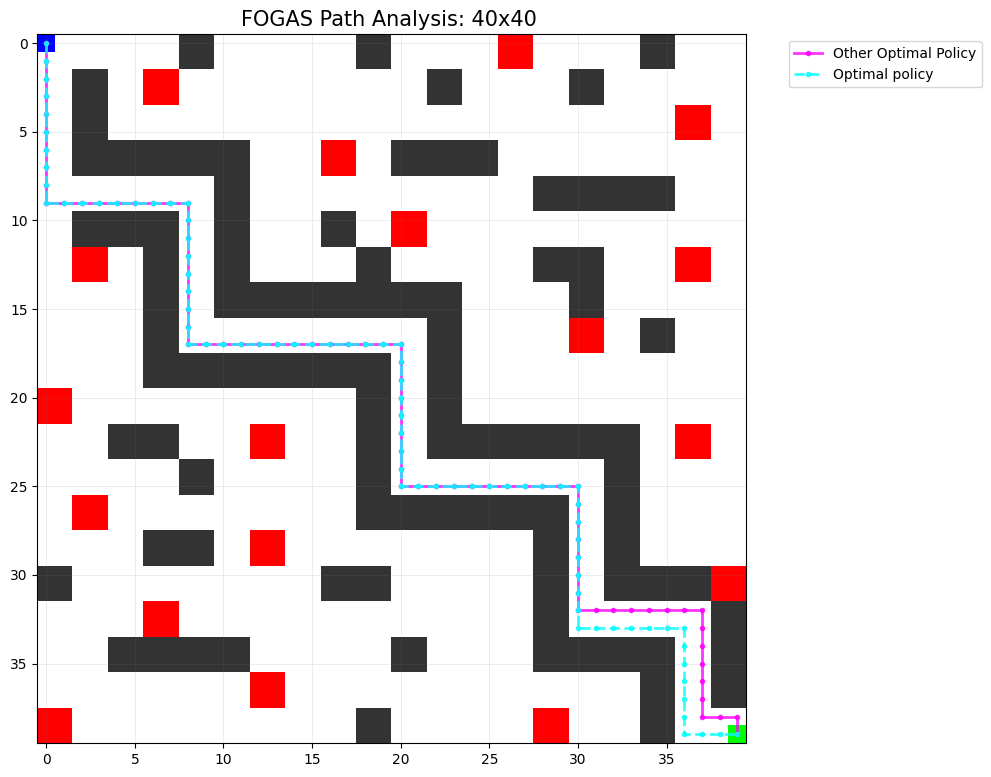

In [11]:
def build_waypoint_policy(mdp, waypoints, grid_size=20):
    """Creates a policy matrix that follows a sequence of (r, c) coordinates."""
    N, A = mdp.N, mdp.A
    pi = np.ones((N, A)) / A  # Start with uniform random everywhere
    
    # helper to get action index (0=Up, 1=Down, 2=Left, 3=Right)
    for i in range(len(waypoints)-1):
        r1, c1 = waypoints[i]
        r2, c2 = waypoints[i+1]
        
        # Fill all states between waypoints with the required direction
        dr, dc = np.sign(r2 - r1), np.sign(c2 - c1)
        curr_r, curr_c = r1, c1
        
        while (curr_r, curr_c) != (r2, c2):
            s = int(curr_r * grid_size + curr_c)
            action = -1
            if dr != 0 and curr_r != r2:
                action = 1 if dr > 0 else 0 # Down or Up
                curr_r += dr
            elif dc != 0 and curr_c != c2:
                action = 3 if dc > 0 else 2 # Right or Left
                curr_c += dc
            
            if action != -1:
                pi[s] = 0.0
                pi[s, action] = 1.0
                
    return torch.tensor(pi, dtype=torch.float64)

new_path_40_waypoints1 = [
    (0,  0),    # → RIGHT to col 1  (instead of going down col 0)
    (9, 0),             # ↓ DOWN  to row 13  (pink goes to row 14 at col 0)
    (9, 8),            # → RIGHT to col 16
    (17, 8), (17, 20),  # ↓ DOWN  to row 15 (pink: 16), → RIGHT to col 30
    (25, 20), (25, 30),  # ↓ DOWN  to row 17 (pink: 18), → RIGHT to col 32
    (32, 30),            # ↓ DOWN  to row 33 (pink: 34)
    (32, 37), (38, 37),  # → RIGHT to col 34, ↓ DOWN to row 35 (pink: 36)
    (38, 39),            # → RIGHT to col 38
    (39, 39),
]

# Build the policy (same function as 20x20, just pass grid_size=40)
parallel_pi_star = build_waypoint_policy(mdp_40, new_path_40_waypoints1, grid_size=40)

# Temporarily swap pi_star to compute paths
pi_fogas_40 = mdp_40.pi_star.clone()

mdp_40.pi_star = parallel_pi_star
new_manual_path_40 = compute_optimal_path(mdp_40, mdp_data_40, size=size_40)

mdp_40.pi_star = pi_fogas_40   # restore
optimal_path_40 = compute_optimal_path(mdp_40, mdp_data_40, size=size_40)

labels = ["Other Optimal Policy", "Optimal policy"]
plot_agent_paths(grid_40, [new_manual_path_40, optimal_path_40], labels=labels)

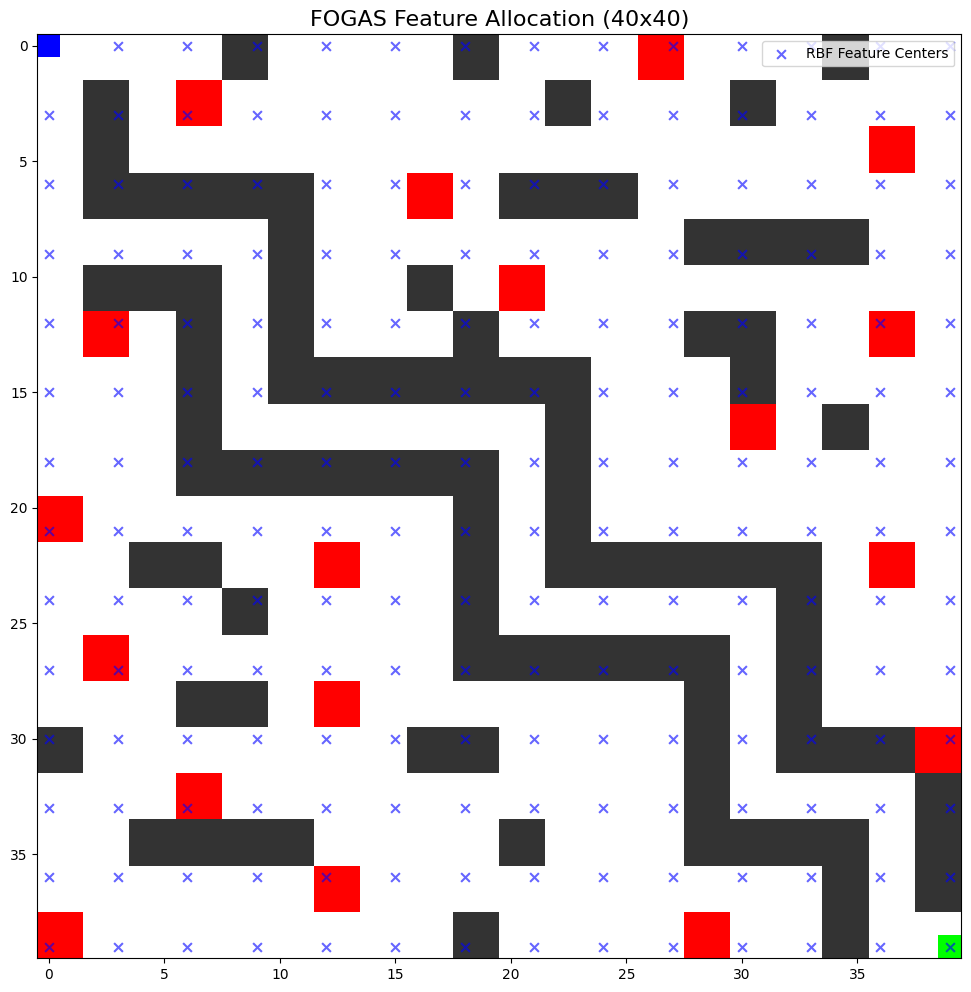

In [8]:
plot_grid_with_centers(grid_data=grid_40, centers=fixed_centers)

### Dataset collection

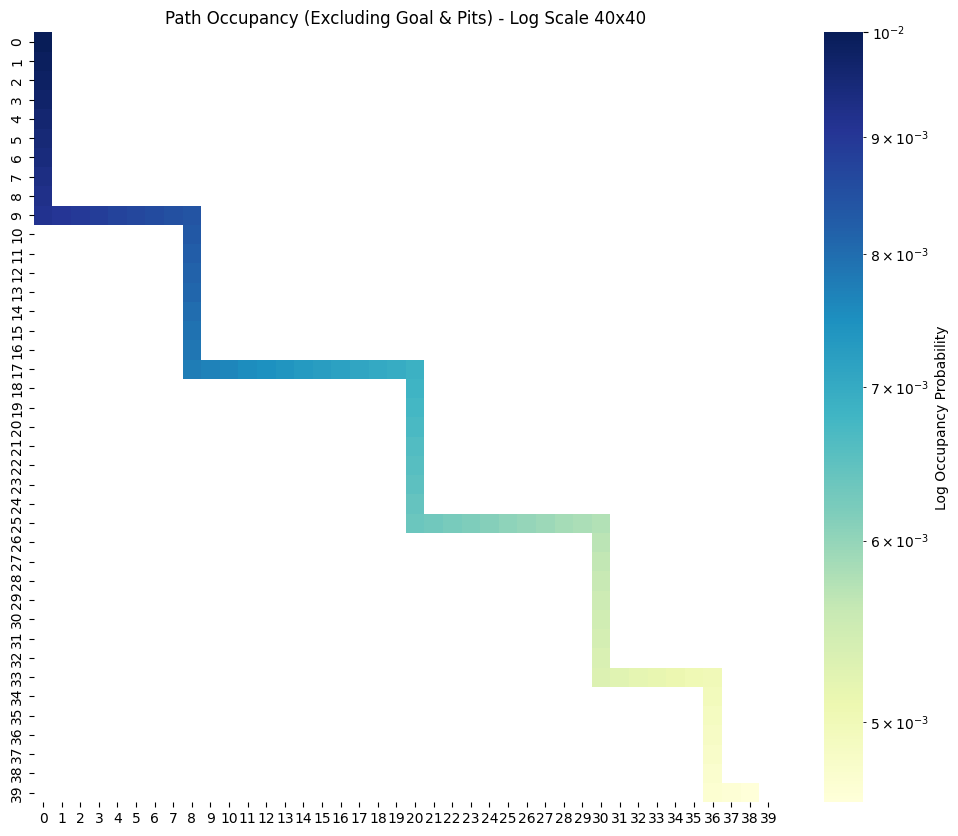

In [9]:
# 1. Get occupancy probabilities for the 40x40 MDP
probs40 = mdp_40.state_mu_star.detach().cpu().numpy().copy()

# 2. Mask the Goal/Pits (Terminal States) for better visual scaling
# Uses the mdp_data_40 containing indices for the 40x40 grid
terminal_indices_40 = list(mdp_data_40['pits']) + [mdp_data_40['goal']]
for idx in terminal_indices_40:
    probs40[idx] = 0.0

# 3. Reshape using the new grid size
grid_size_40 = 40  # matches size_40
occupancy_grid_40 = probs40.reshape(grid_size_40, grid_size_40)

# 4. Plot with Log Normalization
plt.figure(figsize=(12, 10))
sns.heatmap(
    occupancy_grid_40, 
    cmap="YlGnBu", 
    norm=LogNorm(
        vmin=probs40[probs40 > 0].min() if any(probs40 > 0) else 1e-6, 
        vmax=probs40.max()
    ),
    cbar_kws={'label': 'Log Occupancy Probability'}
)

plt.title(f"Path Occupancy (Excluding Goal & Pits) - Log Scale {grid_size_40}x{grid_size_40}")
plt.show()

In [ ]:
# ─── Step 1: recover states left of the wall for the 40×40 grid ──────────────
boundary_40 = trace_staircase_boundary(grid_data_40, start_row=10, start_col=2)

states_left_wall_40 = get_states_left_of_boundary(
    grid_data_40, from_row=10, to_row=39, boundary=boundary_40,
    exclude_walls=True, as_1d=True          # 1-D indices for the 40×40 state space
)
print(f"States left of wall to augment (40×40): {len(states_left_wall_40)}")
print(states_left_wall_40)

# ─── Step 2: collector setup ──────────────────────────────────────────────────
reset_options_40 = {
    'x0': 0.2,
    'occupancy': 0.8
}

collector40 = EnvDataCollector(
    mdp=mdp_40,
    env_name="40grid",
    restricted_states=mdp_data_40["walls"],
    reset_probs=reset_options_40,
    max_steps=200
)

epsilon_policy_40 = (mdp_40.pi_star, 0.0)
epsilon_policy_new_40 = (parallel_pi_star, 0.0)

df_40 = collector40.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy_40, epsilon_policy_new_40, "random"],
    proportions=[0.6, 0.2, 0.2],
    n_steps=100000,
    episode_based=True,
    save_path=str(DATASET_PATH1),
    verbose=True,
    extra_steps=40
)

print(f"\nFinal dataset size (main + manual augmentation): {len(df_40)}")

In [14]:
reset_options_40 = {
    'x0': 0.2,
    'occupancy': 0.8
}

collector40 = EnvDataCollector(
    mdp=mdp_40,
    env_name="40grid",
    restricted_states=mdp_data_40["walls"],
    reset_probs=reset_options_40,
    max_steps=200
)

epsilon_policy_40 = (mdp_40.pi_star, 0.0)
epsilon_policy_new_40 = (parallel_pi_star, 0.0)

df_40 = collector40.collect_mixed_dataset_terminal_aware(
    policies=[epsilon_policy_40, epsilon_policy_new_40, "random"],
    proportions=[0.8, 0.2, 0.0],
    n_steps=70000,
    episode_based=True,
    save_path=str(DATASET_PATH1),
    verbose=True,
    extra_steps=40
)

print(f"\nFinal dataset size (main + manual augmentation): {len(df_40)}")


  MIXED TERMINAL-AWARE DATASET COLLECTION SUMMARY (TORCH)
Total transitions: 70000
Total episodes: 768
Extra steps: 40

Policy Distribution:
  Policy 0: 56933 steps (81.3%) | Target: 80.0% | Episodes: 622
  Policy 1: 13067 steps (18.7%) | Target: 20.0% | Episodes: 147
  Policy 2:     0 steps ( 0.0%) | Target:  0.0% | Episodes: 0

✅ Mixed terminal-aware dataset saved to: /shared/home/mauro.diaz/work/FOGAS/datasets/40grid.csv

Final dataset size (main + manual augmentation): 70000


Total states (40x40): 1600
Walls: 392
Visited: 94
Non-visited non-walls: 1114


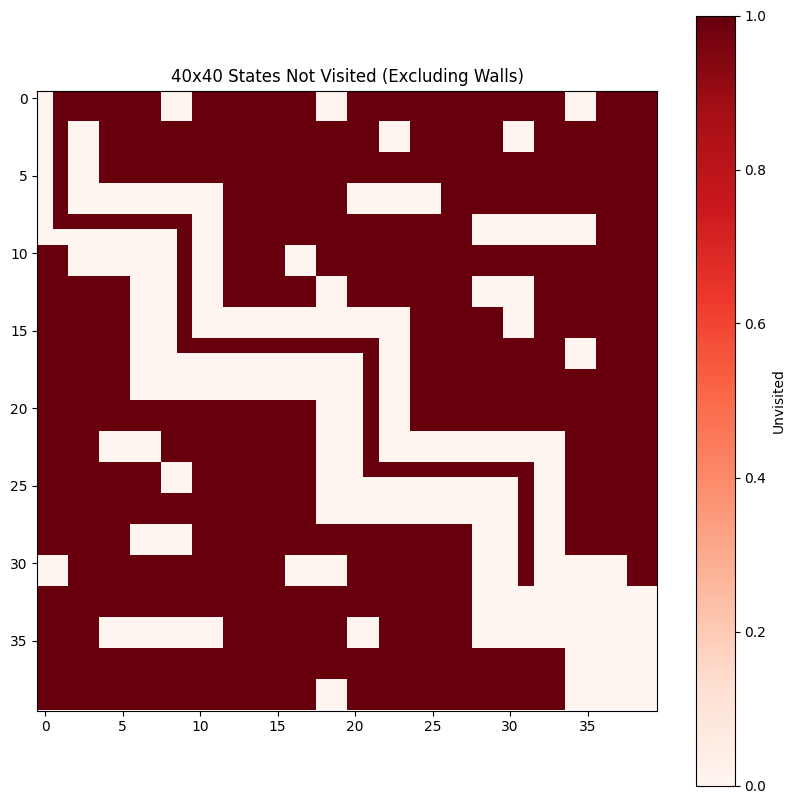

In [15]:
# 1. Get all visited states from your collected 40x40 dataset
visited_states_40 = set(df_40['state'].unique())

# 2. Get the set of wall states for the 40x40 grid
wall_states_40 = set(mdp_data_40['walls'])

# 3. Calculate states that were NOT visited and are NOT walls
all_states_40 = set(range(mdp_40.N))
non_visited_non_walls_40 = all_states_40 - visited_states_40 - wall_states_40

print(f"Total states (40x40): {mdp_40.N}")
print(f"Walls: {len(wall_states_40)}")
print(f"Visited: {len(visited_states_40)}")
print(f"Non-visited non-walls: {len(non_visited_non_walls_40)}")

# Convert indices to (row, col) coordinates for the 40x40 grid
size_40_val = 40
coords_40 = [divmod(s, size_40_val) for s in sorted(list(non_visited_non_walls_40))]

# Create an empty 40x40 map (0 = visited/wall, 1 = missing)
coverage_map_40 = np.zeros((size_40_val, size_40_val))
for s in non_visited_non_walls_40:
    r, c = divmod(s, size_40_val)
    coverage_map_40[r, c] = 1

plt.figure(figsize=(10, 10))
plt.imshow(coverage_map_40, cmap='Reds')
plt.title(f"40x40 States Not Visited (Excluding Walls)")
plt.colorbar(label="Unvisited")
plt.show()

### Solving it

[FOGASSolverVectorized] omega estimated via regression (beta_omega=1.00e-07, n=70000)

     REWARD APPROXIMATION ANALYSIS
Metric                                Value
────────────────────────────────────────────
Max |error|                       10.614110
Mean |error|                       0.636087
RMSE                               2.177377
R² (explained variance)            0.004259

--------------------------------------------------
State  Action         r_true      r_hat      error
──────────────────────────────────────────────────
0            ↑ Up          -0.0100     0.4075     0.4175 ⚠️
0            ↓ Down        -0.0100    -0.0099     0.0001
0            ← Left        -0.0100     0.3602     0.3702 ⚠️
0            → Right       -0.0100     0.0048     0.0148
1            ↑ Up          -0.0100     0.4075     0.4175 ⚠️
1            ↓ Down        -0.0100    -0.0108    -0.0008
1            ← Left        -0.0100     0.3602     0.3702 ⚠️
1            → Right       -0.0100     0.0048   

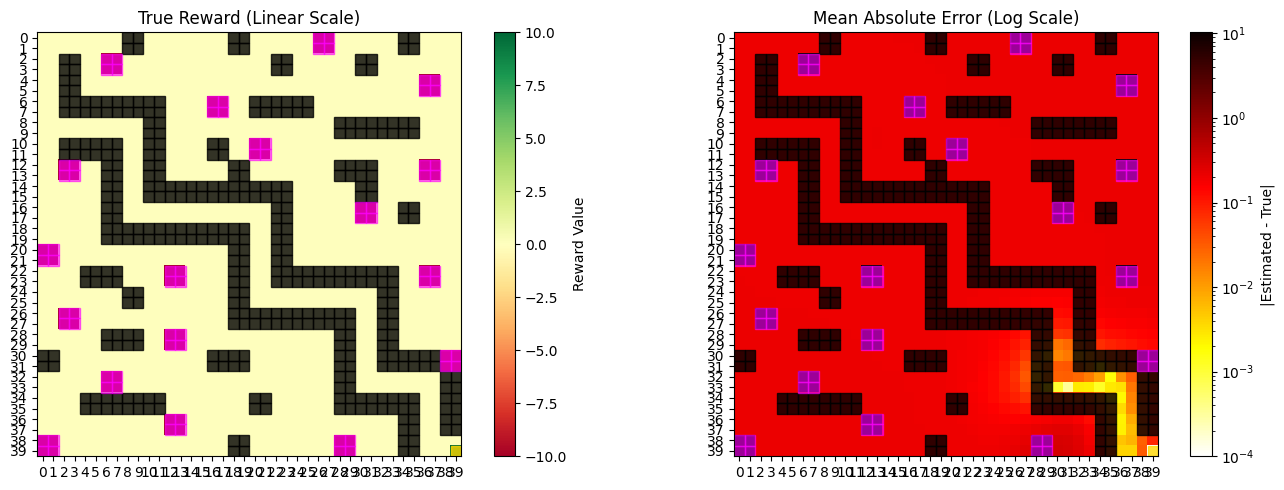

In [16]:
# Initialize the vectorized solver for the 100x100 dataset
solver1_e = FOGASSolverVectorized(
    mdp=mdp_40,
    csv_path=str(DATASET_PATH1),
    device=device,
    beta=1e-7,
    seed=seed
)

# Initialize the evaluator for the 100x100 solver
evaluator1_e = FOGASEvaluator(solver1_e)

# Initialize the hyperparameter optimizer for 100x100
optimizer1_e = FOGASHyperOptimizer(
    solver=solver1_e,
    metric_callable=evaluator1_e.get_metric("reward"), 
    seed=seed
)

# Run the reward approximation analysis on the 100x100 environment
evaluator1_e.analyze_reward_approximation(
    walls=mdp_data_40["walls"], 
    pits=mdp_data_40["pits"], 
    goal=mdp_data_40["goal"],
    print_each=True
)


In [17]:
solver1_e.run(
    alpha=5e-5,
    eta=2e-5, 
    rho=1.0, 
    tqdm_print=True, 
    T=80000
)

# Print the optimal path reaching the 100x100 goal (State 9999)
evaluator1_e.print_optimal_path(goal_state=mdp_data_40["goal"], max_steps = 100)
evaluator1_e.print_policy()

FOGAS: 100%|█████████████████████████████████████████████████████████████████████████████████████████████| 80000/80000 [06:22<00:00, 209.20it/s]



  OPTIMAL PATH VISUALIZATION - Learned Policy (π_FOGAS)

Initial State: 0
Goal State: 1599
Discount Factor (γ): 0.99

----------------------------------------------------------------------

  Step   0 │ State: 0        │ Action: 1       │ Reward:  -0.010 │ → 40
  Step   1 │ State: 40       │ Action: 1       │ Reward:  -0.010 │ → 80
  Step   2 │ State: 80       │ Action: 1       │ Reward:  -0.010 │ → 120
  Step   3 │ State: 120      │ Action: 1       │ Reward:  -0.010 │ → 160
  Step   4 │ State: 160      │ Action: 1       │ Reward:  -0.010 │ → 200
  Step   5 │ State: 200      │ Action: 1       │ Reward:  -0.010 │ → 240
  Step   6 │ State: 240      │ Action: 1       │ Reward:  -0.010 │ → 280
  Step   7 │ State: 280      │ Action: 1       │ Reward:  -0.010 │ → 320
  Step   8 │ State: 320      │ Action: 1       │ Reward:  -0.010 │ → 360
  Step   9 │ State: 360      │ Action: 3       │ Reward:  -0.010 │ → 361
  Step  10 │ State: 361      │ Action: 3       │ Reward:  -0.010 │ → 362
  Step  

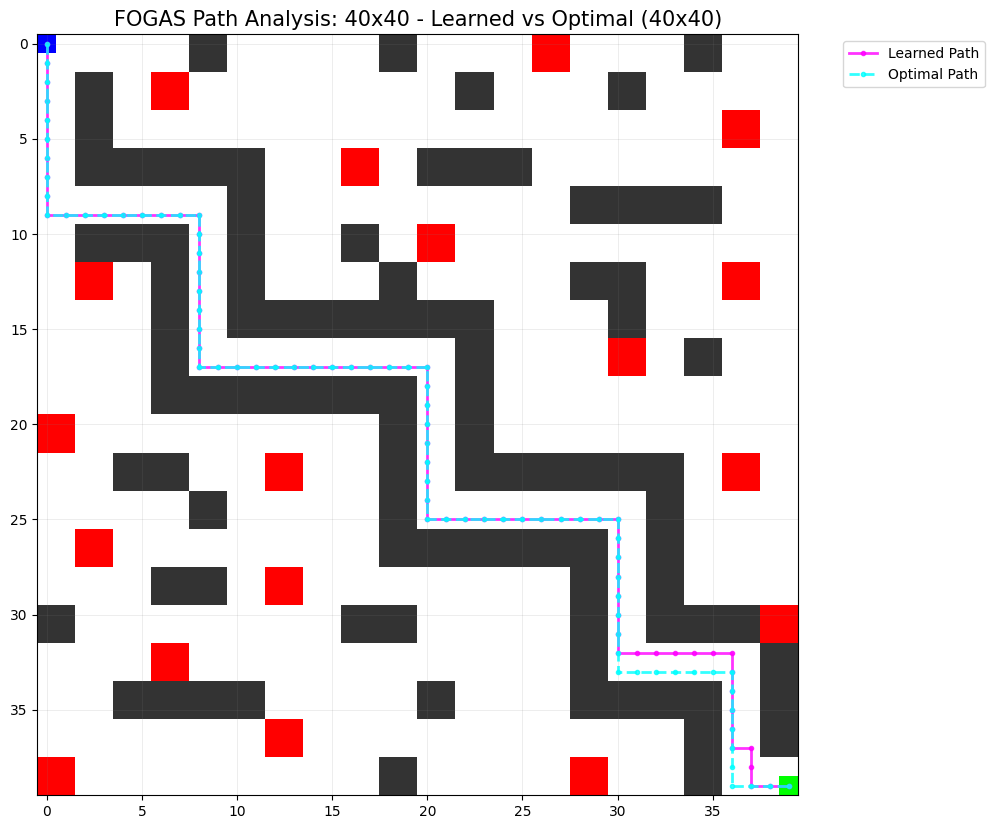

In [18]:
# 1. Simulate the trajectories for the 40x40 grid
# Assuming your evaluator is named evaluator_40_e
traj_40 = evaluator1_e.simulate_trajectory(goal_state=mdp_data_40["goal"])
traj_opt_40 = evaluator1_e.simulate_trajectory(pi=evaluator1_e.mdp.pi_star, goal_state=mdp_data_40["goal"])

size_40_grid = grid_40.shape[0]

# 2. Extract path coordinates and include the final 'next_state' (the goal)
path_coords_40 = [divmod(step['state'], size_40_grid) for step in traj_40]
if traj_40:
    path_coords_40.append(divmod(traj_40[-1]['next_state'], size_40_grid))

path_opt_40 = [divmod(step['state'], size_40_grid) for step in traj_opt_40]
if traj_opt_40:
    path_opt_40.append(divmod(traj_opt_40[-1]['next_state'], size_40_grid))

# 3. Plot both to see how close your learned policy is to optimal
# Using the updated plot_agent_paths with labels if you implemented it
plot_agent_paths(
    grid_40, 
    [path_coords_40, path_opt_40], 
    labels=["Learned Path", "Optimal Path"],
    title_suffix="- Learned vs Optimal (40x40)"
)

In [4]:
from pathlib import Path
import pandas as pd

DATA_DIR = Path("/shared/home/mauro.diaz/work/FOGAS/datasets/grids")

FILES = {
    "A – Manual Augmentation":   "grid_search_dataset_40grid_A.csv",
    "B – Epsilon Variation":      "grid_search_dataset_40grid_B.csv",
    "C – Random-Start Coverage":  "grid_search_dataset_40grid_C.csv",
}

# ── Sort keys per family ──────────────────────────────────────────
SORT_BY = {
    "A – Manual Augmentation":  ["n_uniform", "coverage"],
    "B – Epsilon Variation":    ["epsilon", "proportions"],
    "C – Random-Start Coverage":["p_rand"],
}

SEP = "═" * 72

for family, fname in FILES.items():
    p = DATA_DIR / fname
    print(f"\n{SEP}")
    print(f"  {family}")
    print(SEP)

    if not p.exists():
        print(f"  ⚠️  File not found: {p}\n")
        continue

    df = pd.read_csv(p)
    sort_cols = [c for c in SORT_BY[family] if c in df.columns]
    df = df.sort_values(sort_cols) if sort_cols else df

    # ── Header ────────────────────────────────────────────────────
    print(f"  Rows: {len(df)}  |  Columns: {list(df.columns)}\n")

    # ── Metric summary ────────────────────────────────────────────
    metric_cols = ["convergence", "coverage", "final_reward", "q_gap"]
    present = [c for c in metric_cols if c in df.columns]
    if present:
        print(f"  {'Metric':<20} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
        print(f"  {'-'*62}")
        for col in present:
            m, s, lo, hi = df[col].mean(), df[col].std(), df[col].min(), df[col].max()
            print(f"  {col:<20} {m:>10.4f} {s:>10.4f} {lo:>10.4f} {hi:>10.4f}")
        print()

    # ── Full table (ordered) ──────────────────────────────────────
    display_cols = sort_cols + [c for c in df.columns if c not in sort_cols and c != "experiment"]
    print(df[display_cols].to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    print()

print(f"\n{SEP}")
print("  ✅ Done")
print(SEP)



════════════════════════════════════════════════════════════════════════
  A – Manual Augmentation
════════════════════════════════════════════════════════════════════════
  Rows: 20  |  Columns: ['experiment', 'n_uniform', 'coverage', 'n_unvisited_pairs', 'total_aug_rows', 'total_dataset_size', 'convergence', 'conv_dist', 'final_reward', 'v_gap', 'q_gap', 'path_len']

  Metric                     Mean        Std        Min        Max
  --------------------------------------------------------------
  convergence              0.4000     0.5026     0.0000     1.0000
  coverage                 0.6000     0.2902     0.2000     1.0000
  final_reward            -0.4985     1.2701    -2.7538     1.0370
  q_gap                   42.6804    16.0833    15.7253    63.2012

 n_uniform  coverage  n_unvisited_pairs  total_aug_rows  total_dataset_size  convergence  conv_dist  final_reward   v_gap   q_gap  path_len
         1    0.2000                889             889               70889           

  CSV source : /shared/home/mauro.diaz/work/FOGAS/datasets/grids
  PNG output : /shared/home/mauro.diaz/work/FOGAS/testing_vectorized/plots

─── Family A: Manual Augmentation ───
  Loaded grid_search_dataset_40grid_A.csv — 20 rows, columns: ['experiment', 'n_uniform', 'coverage', 'n_unvisited_pairs', 'total_aug_rows', 'total_dataset_size', 'convergence', 'conv_dist', 'final_reward', 'v_gap', 'q_gap', 'path_len']


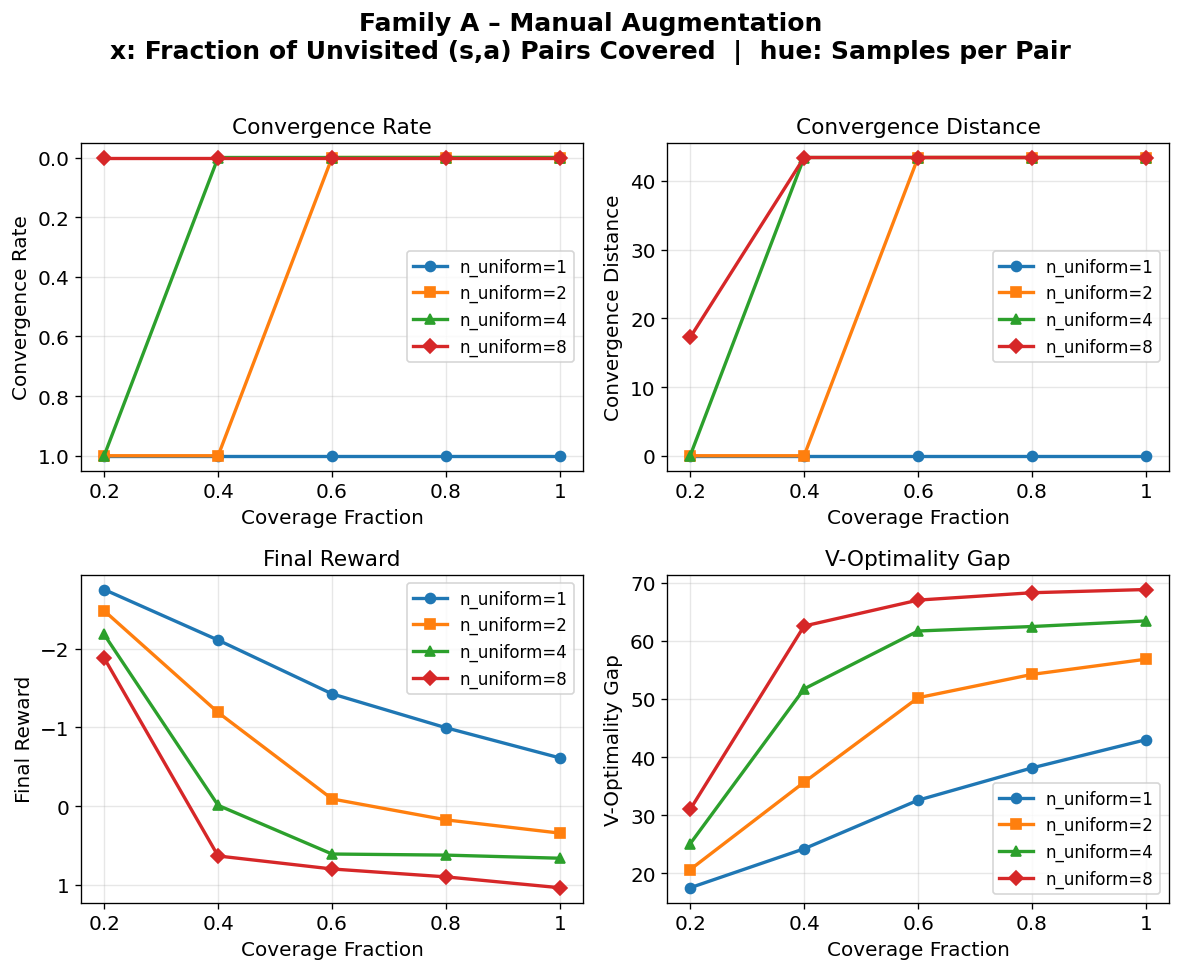

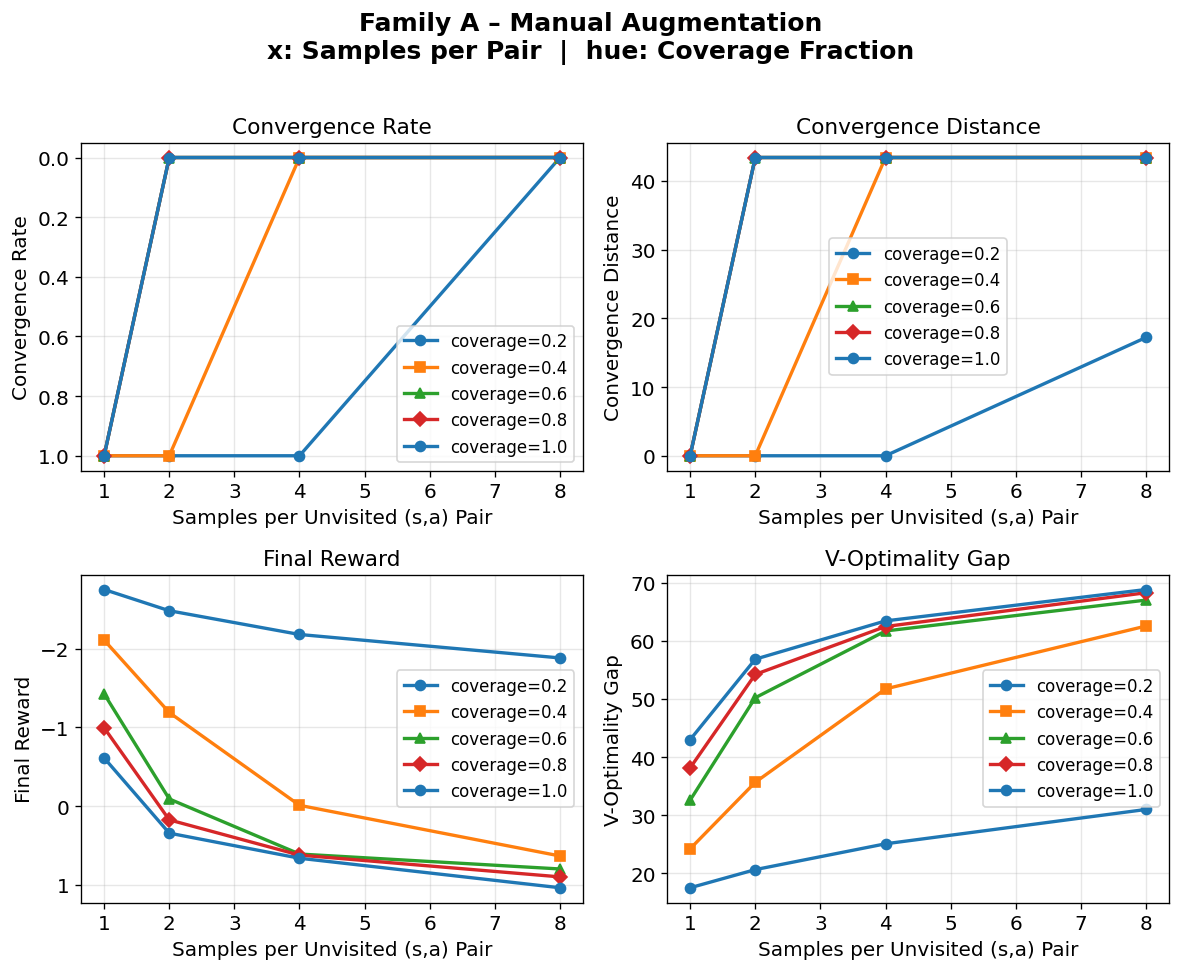

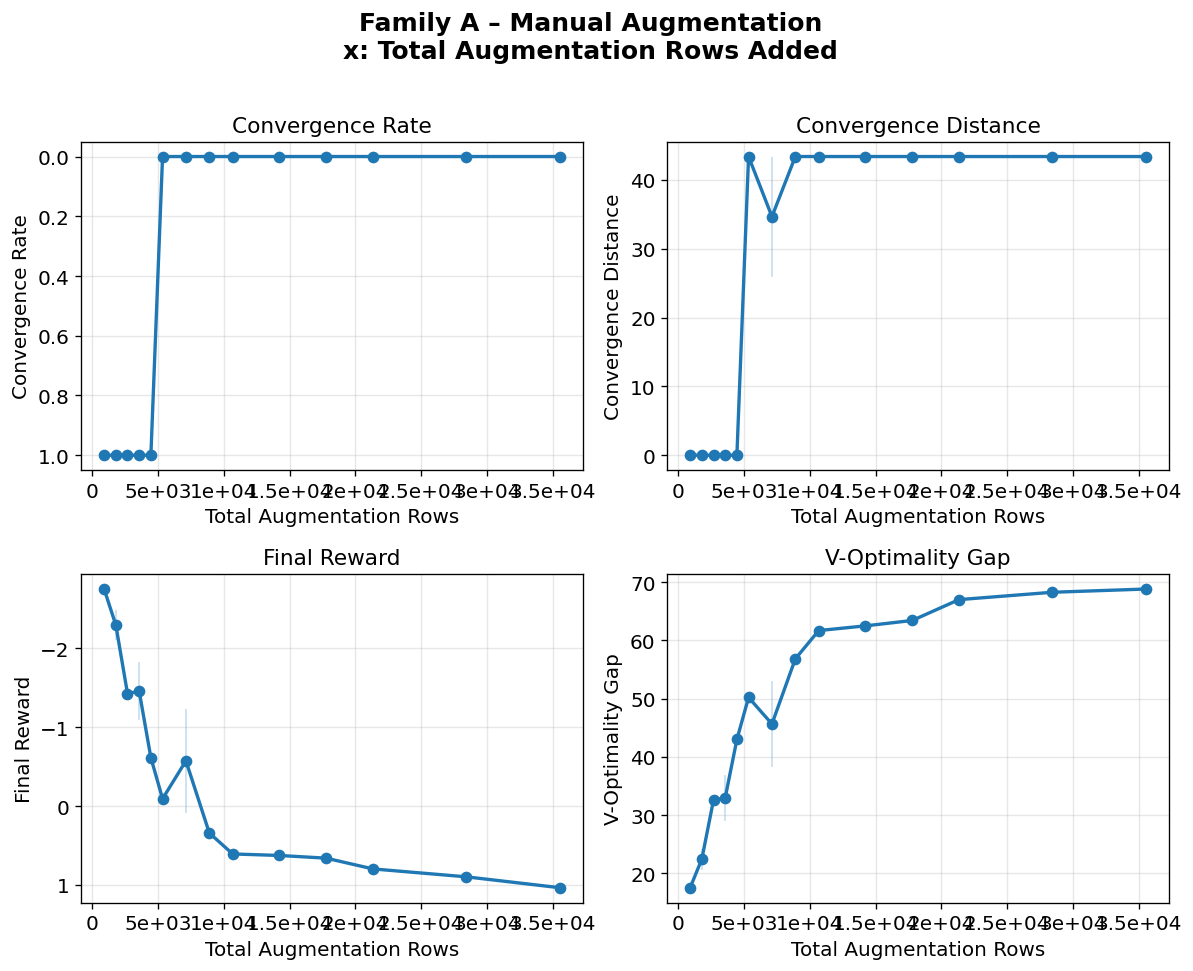


─── Family B: Epsilon Variation ───
  Loaded grid_search_dataset_40grid_B.csv — 18 rows, columns: ['experiment', 'proportions', 'p_opt', 'p_alt', 'p_rand', 'epsilon', 'convergence', 'conv_dist', 'final_reward', 'v_gap', 'q_gap', 'path_len']


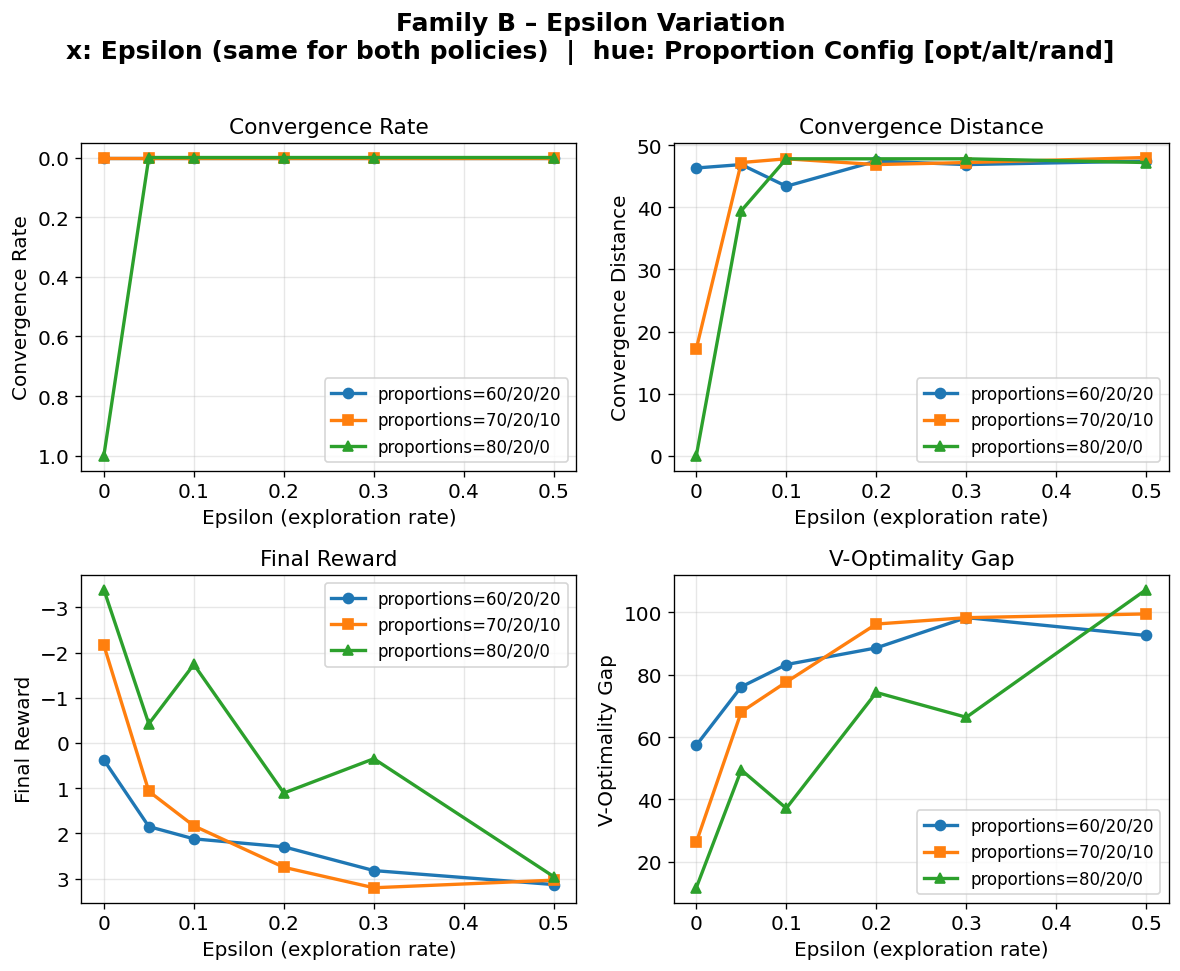

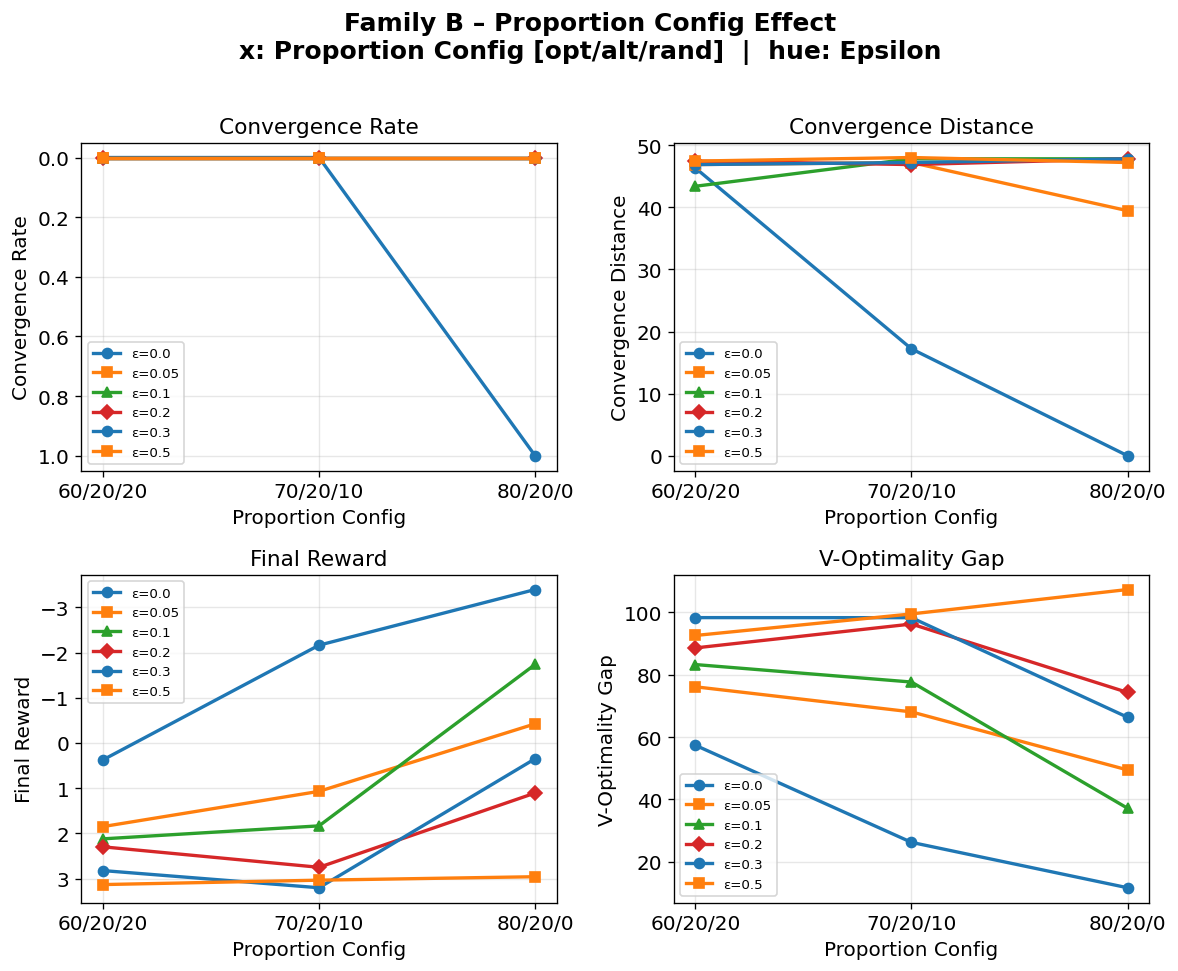


─── Family C: Random-Start Policy Coverage ───
  Loaded grid_search_dataset_40grid_C.csv — 6 rows, columns: ['experiment', 'p_rand', 'p_opt', 'p_alt', 'n_guided', 'n_random', 'convergence', 'conv_dist', 'final_reward', 'v_gap', 'q_gap', 'path_len']


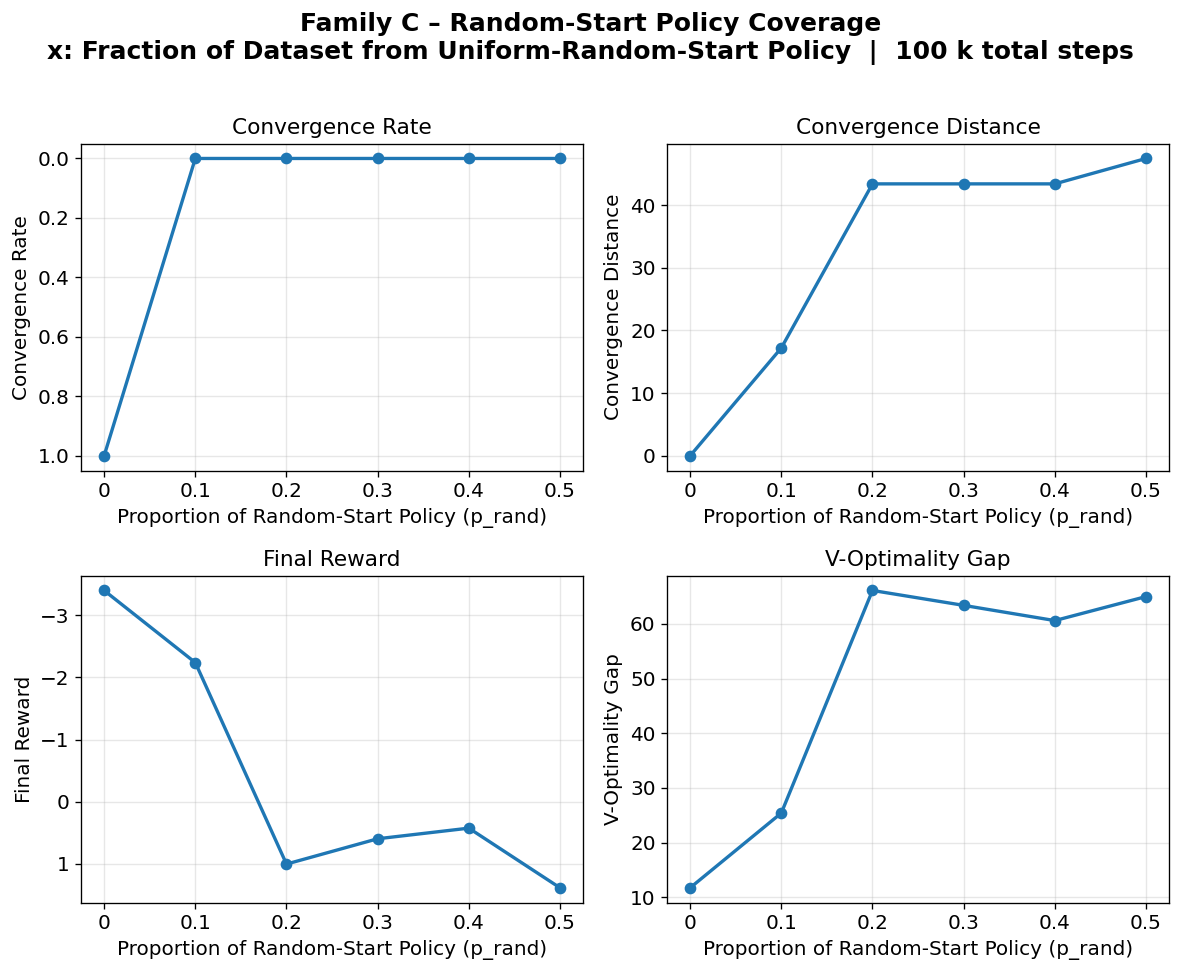


─── Combined Convergence Overview ───


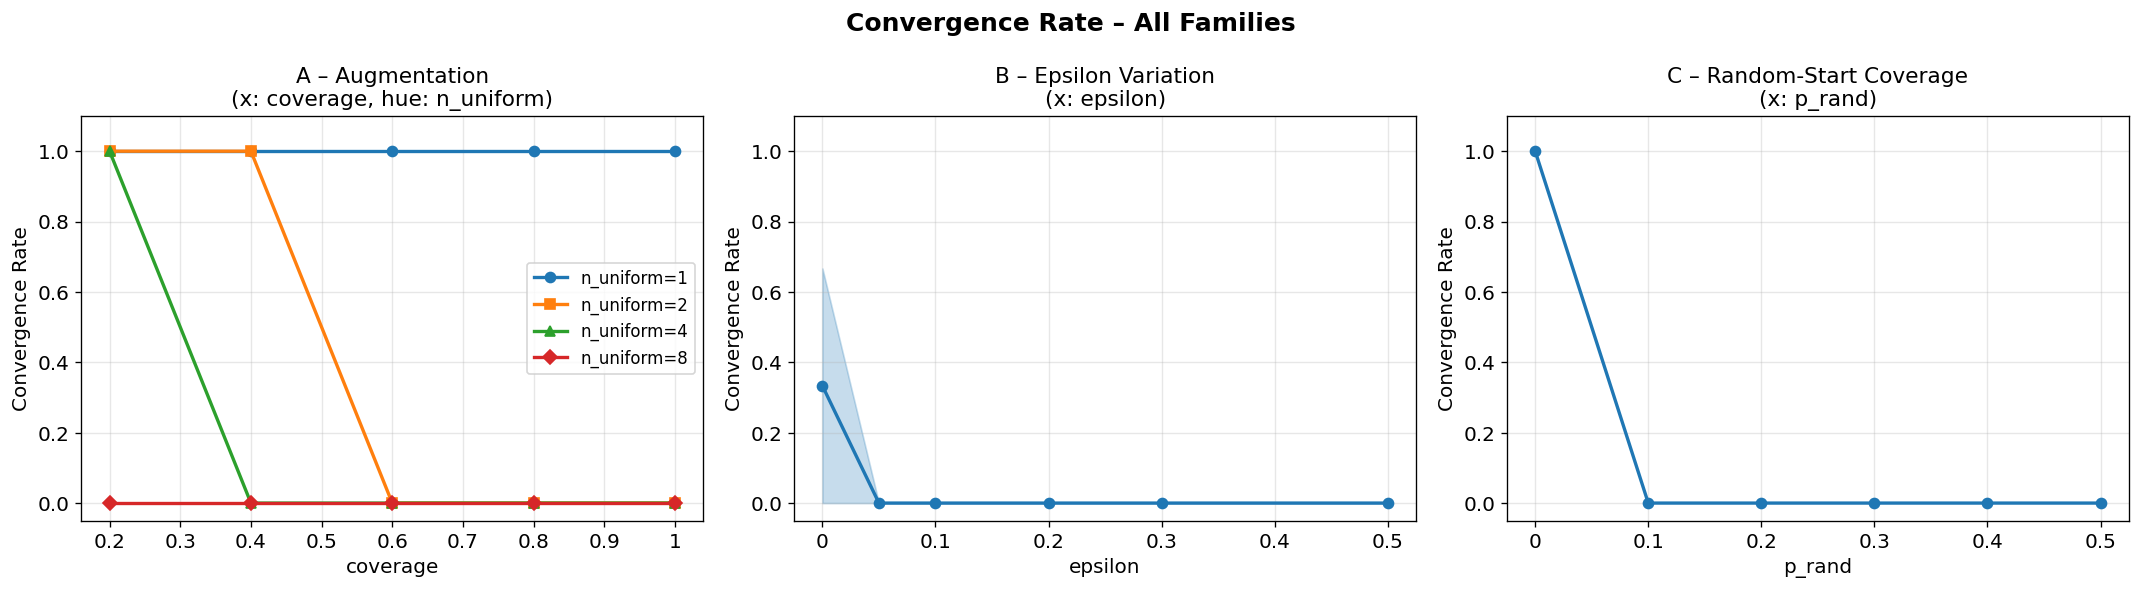


✅ Plotting complete.


In [3]:
SAVE_FIGS = False   # or True to save PNGs
%run /shared/home/mauro.diaz/work/FOGAS/testing_vectorized/utils/plot_dataset_grid_search_40grid.py